## Diffusion Models / Flow Matching - cosine schedule

On considere une interpolation de la forme

$$X_t = \alpha_t X_0 + \beta_t X_1, \qquad t \in [0,1].$$

Les conditions aux bords sont:

$$\alpha_0 = 1, \quad \beta_0 = 0, \quad \alpha_1 = 0, \quad \beta_1 = 1.$$

##  1. Choix de `a` et `b` pour le cosine schedule

On pose:

$$\alpha_t = \cos(at), \qquad \beta_t = \sin(bt).$$

A `t = 0`:

$$\alpha_0 = \cos(0) = 1,$$

$$\beta_0 = \sin(0) = 0.$$

Les deux premieres conditions sont donc automatiquement verifiees.

A `t = 1`, il faut:

$$\cos(a) = 0,$$

$$\sin(b) = 1.$$

Les plus petites valeurs positives qui verifient ces conditions sont:

$$a = \frac{\pi}{2}, \qquad b = \frac{\pi}{2}.$$

Donc le cosine schedule est:

$$\boxed{\alpha_t = \cos\left(\frac{\pi}{2}t\right)}, \qquad \boxed{\beta_t = \sin\left(\frac{\pi}{2}t\right)}.$$

## 2. Calcul de $\frac{dX_t}{dt}$ pour le cosine schedule

Avec:

$$X_t = \alpha_t X_0 + \beta_t X_1,$$

on a:

$$\frac{dX_t}{dt} = \frac{d\alpha_t}{dt}X_0 + \frac{d\beta_t}{dt}X_1.$$

Pour le cosine schedule:

$$\alpha_t = \cos\left(\frac{\pi}{2}t\right), \qquad \beta_t = \sin\left(\frac{\pi}{2}t\right).$$

Donc:

$$\frac{d\alpha_t}{dt} = -\frac{\pi}{2}\sin\left(\frac{\pi}{2}t\right),$$

$$\frac{d\beta_t}{dt} = \frac{\pi}{2}\cos\left(\frac{\pi}{2}t\right).$$

Finalement:

$$\boxed{\frac{dX_t}{dt} = -\frac{\pi}{2}\sin\left(\frac{\pi}{2}t\right)X_0 + \frac{\pi}{2}\cos\left(\frac{\pi}{2}t\right)X_1}.$$

In [1]:
import numpy as np
import matplotlib.pyplot as plt


def linear_schedule(t):
    """Return alpha, beta, d_alpha/dt, d_beta/dt for the linear schedule."""
    alpha = 1.0 - t
    beta = t
    d_alpha = -np.ones_like(t)
    d_beta = np.ones_like(t)
    return alpha, beta, d_alpha, d_beta


def cosine_schedule(t):
    """Return alpha, beta, d_alpha/dt, d_beta/dt for the cosine schedule."""
    c = np.pi / 2.0
    alpha = np.cos(c * t)
    beta = np.sin(c * t)
    d_alpha = -c * np.sin(c * t)
    d_beta = c * np.cos(c * t)
    return alpha, beta, d_alpha, d_beta


def interpolate(X0, X1, t, schedule):
    alpha, beta, _, _ = schedule(np.asarray(t))
    return alpha * X0 + beta * X1


def velocity(X0, X1, t, schedule):
    _, _, d_alpha, d_beta = schedule(np.asarray(t))
    return d_alpha * X0 + d_beta * X1

## 3. Le schedule lineaire n'est pas variance preserving

On considere:

$$X_t = (1-t)X_0 + tX_1,$$

avec:

$$X_0 \sim \mathcal{N}(0,1), \qquad X_1 \sim \mathcal{N}(1,1).$$

On suppose $X_0$ et $X_1$ independantes. A `t = 1/2`:

$$X_{1/2} = \frac{1}{2}X_0 + \frac{1}{2}X_1.$$

La variance vaut:

$$\operatorname{Var}(X_{1/2}) = \frac{1}{4}\operatorname{Var}(X_0) + \frac{1}{4}\operatorname{Var}(X_1).$$

Comme les deux variances valent `1`:

$$\operatorname{Var}(X_{1/2}) = \frac{1}{4} + \frac{1}{4} = \frac{1}{2}.$$

La variance initiale et finale vaut `1`, mais au milieu elle vaut `1/2`. Le schedule lineaire n'est donc pas variance preserving.

## 4. Le cosine schedule est variance preserving

Pour le cosine schedule:

$$X_t = \cos\left(\frac{\pi}{2}t\right)X_0 + \sin\left(\frac{\pi}{2}t\right)X_1.$$

A `t = 1/2`:

$$X_{1/2} = \cos\left(\frac{\pi}{4}\right)X_0 + \sin\left(\frac{\pi}{4}\right)X_1.$$

Or:

$$\cos\left(\frac{\pi}{4}\right) = \sin\left(\frac{\pi}{4}\right) = \frac{\sqrt{2}}{2}.$$

Donc:

$$\operatorname{Var}(X_{1/2}) = \left(\frac{\sqrt{2}}{2}\right)^2 \operatorname{Var}(X_0) + \left(\frac{\sqrt{2}}{2}\right)^2 \operatorname{Var}(X_1).$$

Comme les deux variances valent `1`:

$$\operatorname{Var}(X_{1/2}) = \frac{1}{2} + \frac{1}{2} = 1.$$

Plus generalement, pour tout `t`:

$$\operatorname{Var}(X_t) = \alpha_t^2 + \beta_t^2 = \cos^2\left(\frac{\pi}{2}t\right) + \sin^2\left(\frac{\pi}{2}t\right) = 1.$$

Le cosine schedule est donc variance preserving.

## 5. Pourquoi est-ce un avantage ?

Un schedule variance preserving garde l'echelle typique des donnees constante pendant le transport. Geometriquement, les points ne se contractent pas artificiellement vers une region de faible variance au milieu de la trajectoire avant de se re-dilater vers la distribution cible.

C'est utile car le champ de vitesse a apprendre est plus regulier: le modele n'a pas besoin de gerer un goulet d'etranglement artificiel dans lequel les echantillons deviennent trop concentres. En pratique, cela donne souvent une interpolation plus stable et une geometrie de generation plus naturelle.

## 6. Verification experimentale en dimension 2

On modifie la distribution cible pour avoir:

$$\mu_1 = \mathcal{N}((1,1), I_2).$$

La distribution source est:

$$\mu_0 = \mathcal{N}((0,0), I_2).$$

On genere des trajectoires avec le schedule lineaire et le cosine schedule, puis on calcule la variance empirique a chaque pas de temps.

In [2]:
rng = np.random.default_rng(0)

n_samples = 100_000
dim = 2

# Source: N((0, 0), I_2)
X0 = rng.normal(loc=0.0, scale=1.0, size=(n_samples, dim))

# Target: N((1, 1), I_2)
X1 = rng.normal(loc=1.0, scale=1.0, size=(n_samples, dim))

ts = np.linspace(0.0, 1.0, 101)


def empirical_variance_curve(X0, X1, ts, schedule):
    variances = []
    means = []
    for t in ts:
        Xt = interpolate(X0, X1, t, schedule)
        variances.append(Xt.var(axis=0, ddof=1))
        means.append(Xt.mean(axis=0))
    return np.array(means), np.array(variances)


linear_means, linear_vars = empirical_variance_curve(X0, X1, ts, linear_schedule)
cosine_means, cosine_vars = empirical_variance_curve(X0, X1, ts, cosine_schedule)

linear_var_mean = linear_vars.mean(axis=1)
cosine_var_mean = cosine_vars.mean(axis=1)

print("Linear schedule:")
print(f"  variance at t=0.00: {linear_var_mean[0]:.4f}")
print(f"  variance at t=0.50: {linear_var_mean[len(ts)//2]:.4f}")
print(f"  variance at t=1.00: {linear_var_mean[-1]:.4f}")
print(f"  min variance: {linear_var_mean.min():.4f}")

print("\nCosine schedule:")
print(f"  variance at t=0.00: {cosine_var_mean[0]:.4f}")
print(f"  variance at t=0.50: {cosine_var_mean[len(ts)//2]:.4f}")
print(f"  variance at t=1.00: {cosine_var_mean[-1]:.4f}")
print(f"  min variance: {cosine_var_mean.min():.4f}")
print(f"  max variance: {cosine_var_mean.max():.4f}")

Linear schedule:
  variance at t=0.00: 1.0024
  variance at t=0.50: 0.5001
  variance at t=1.00: 1.0032
  min variance: 0.5001

Cosine schedule:
  variance at t=0.00: 1.0024
  variance at t=0.50: 1.0002
  variance at t=1.00: 1.0032
  min variance: 1.0002
  max variance: 1.0032


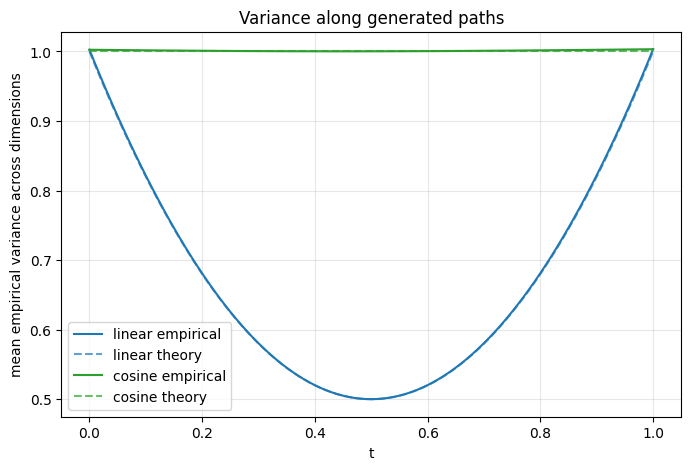

In [3]:
linear_theory = (1.0 - ts) ** 2 + ts ** 2
cosine_theory = np.ones_like(ts)

plt.figure(figsize=(8, 5))
plt.plot(ts, linear_var_mean, label="linear empirical", color="tab:blue")
plt.plot(ts, linear_theory, "--", label="linear theory", color="tab:blue", alpha=0.7)
plt.plot(ts, cosine_var_mean, label="cosine empirical", color="tab:green")
plt.plot(ts, cosine_theory, "--", label="cosine theory", color="tab:green", alpha=0.7)
plt.xlabel("t")
plt.ylabel("mean empirical variance across dimensions")
plt.title("Variance along generated paths")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

Les observations experimentales confirment les predictions theoriques:

- avec le schedule lineaire, la variance descend autour de `0.5` au milieu de la trajectoire;
- avec le cosine schedule, la variance reste proche de `1` pour tout `t`.

Le schedule lineaire n'est donc pas variance preserving, tandis que le cosine schedule l'est.

## Flow Matching en PyTorch avec cosine schedule: Gaussian $\rightarrow$ Moons

Maintenant on apprend un vrai champ de vitesse $v_\theta(x,t)$ avec PyTorch, en gardant l'esprit des notations du PDF.

Dans le PDF, l'interpolation de base est lineaire:

$$X_t = (1-t)X_0 + tX_1,$$

et dans ce cas seulement:

$$\frac{dX_t}{dt} = X_1 - X_0.$$

Ici, on veut utiliser le **cosine schedule**. On remplace donc l'interpolation lineaire par:

$$X_t = \alpha_t X_0 + \beta_t X_1,$$

avec:

$$\alpha_t = \cos\left(\frac{\pi}{2}t\right), \qquad \beta_t = \sin\left(\frac{\pi}{2}t\right).$$

Les conditions aux bords restent correctes:

$$X_0 \sim \mu_0 = \mathcal{N}(0,I_2), \qquad X_1 \sim \mu_1 = \text{moons}.$$

Mais la vitesse cible change. Comme:

$$X_t = \alpha_t X_0 + \beta_t X_1,$$

on a:

$$\frac{dX_t}{dt} = \dot{\alpha}_t X_0 + \dot{\beta}_t X_1.$$

Pour le cosine schedule:

$$\dot{\alpha}_t = -\frac{\pi}{2}\sin\left(\frac{\pi}{2}t\right),$$

$$\dot{\beta}_t = \frac{\pi}{2}\cos\left(\frac{\pi}{2}t\right).$$

Donc la cible d'entrainement est:

$$y_{train} = \dot{\alpha}_t X_0 + \dot{\beta}_t X_1.$$

Le reseau apprend:

$$f_\theta(X_t,t) \approx v_t(X_t),$$

avec, pour cette interpolation cosinus:

$$v_t(x) = \mathbb{E}\left[\dot{\alpha}_t X_0 + \dot{\beta}_t X_1 \mid X_t=x\right].$$

Pour generer, on part d'un bruit gaussien puis on integre l'ODE apprise:

$$\frac{dX_t}{dt} = f_\theta(X_t,t), \qquad X_0 \sim \mathcal{N}(0,I_2).$$

In [ ]:
import torch
from torch import nn
from sklearn.datasets import make_moons
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
from tqdm.auto import tqdm

rng = np.random.default_rng(123)
torch.manual_seed(123)

device = torch.device("mps")

print("Using device:", device)

Using device: mps


In [5]:

moons, _ = make_moons(n_samples=3500, noise=0.06, random_state=42)
moons = moons * np.array([1.25, 1.15]) + np.array([0.0, 0.15])
moons_torch = torch.tensor(moons, dtype=torch.float32, device=device)

def cosine_schedule_torch(t):
    c = torch.pi / 2.0
    alpha = torch.cos(c * t)
    beta = torch.sin(c * t)
    d_alpha = -c * torch.sin(c * t)
    d_beta = c * torch.cos(c * t)
    return alpha, beta, d_alpha, d_beta


def model_features_torch(x, t):
    """Input features for v_theta: position + time + simple time embedding."""
    if t.ndim == 0:
        t = t.expand(x.shape[0], 1)
    elif t.ndim == 1:
        t = t[:, None]
    return torch.cat([x, t, torch.sin(torch.pi * t), torch.cos(torch.pi * t)], dim=1)


In [6]:
n_train = 60_000
x0_train = torch.randn(n_train, 2, device=device)
x1_indices = torch.randint(0, len(moons), (n_train,), device=device)
x1_train = moons_torch[x1_indices]
t_train = torch.rand(n_train, 1, device=device)

# Cosine schedule: X_t = alpha_t X_0 + beta_t X_1.
alpha, beta, d_alpha, d_beta = cosine_schedule_torch(t_train)
xt_train = alpha * x0_train + beta * x1_train

# For the cosine interpolation, dX_t/dt = d_alpha_t X_0 + d_beta_t X_1.
y_train = d_alpha * x0_train + d_beta * x1_train

X_train = model_features_torch(xt_train, t_train)

# Manual standardization, kept as torch tensors.
X_mean = X_train.mean(dim=0, keepdim=True)
X_std = X_train.std(dim=0, keepdim=True).clamp_min(1e-6)
y_mean = y_train.mean(dim=0, keepdim=True)
y_std = y_train.std(dim=0, keepdim=True).clamp_min(1e-6)

X_train_scaled = (X_train - X_mean) / X_std
y_train_scaled = (y_train - y_mean) / y_std

In [7]:
class FlowMLP(nn.Module):
    def __init__(self, in_dim=5, hidden_dim=256, out_dim=2):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, hidden_dim),
            nn.SiLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.SiLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.SiLU(),
            nn.Linear(hidden_dim, out_dim),
        )

    def forward(self, x):
        return self.net(x)


flow_model = FlowMLP().to(device)
optimizer = torch.optim.AdamW(flow_model.parameters(), lr=7e-4, weight_decay=1e-5)
loss_fn = nn.MSELoss()

batch_size = 2048
n_steps = 3000
loss_history = []

flow_model.train()
for step in range(n_steps):
    batch_indices = torch.randint(0, n_train, (batch_size,), device=device)
    pred = flow_model(X_train_scaled[batch_indices])
    loss = loss_fn(pred, y_train_scaled[batch_indices])

    optimizer.zero_grad(set_to_none=True)
    loss.backward()
    optimizer.step()

    loss_history.append(float(loss.detach().cpu()))

    if (step + 1) % 500 == 0:
        print(f"step {step + 1:4d}/{n_steps} | loss = {loss_history[-1]:.4f}")

print(f"Final training loss: {loss_history[-1]:.4f}")


step  500/3000 | loss = 0.8082
step 1000/3000 | loss = 0.8501
step 1500/3000 | loss = 0.8040
step 2000/3000 | loss = 0.7732
step 2500/3000 | loss = 0.7863
step 3000/3000 | loss = 0.7818
Final training loss: 0.7818


In [8]:

@torch.no_grad()
def predict_velocity_torch(x, t):
    """ fonction de velocité via la méthode forward du réseau de neurones entraîné. On standardise les entrées et sorties pour la stabilité numérique."""
    if not torch.is_tensor(t):
        t = torch.full((x.shape[0], 1), float(t), dtype=torch.float32, device=device)
    features = model_features_torch(x, t)
    features_scaled = (features - X_mean) / X_std
    velocity_scaled = flow_model(features_scaled)
    return velocity_scaled * y_std + y_mean


@torch.no_grad()
def generate_with_learned_flow(n_samples=3000, n_ode_steps=160, seed=0):
    """ Simulation via méthode euler"""
    generator = torch.Generator(device=device)
    generator.manual_seed(seed)
    x = torch.randn(n_samples, 2, generator=generator, device=device)
    dt = 1.0 / n_ode_steps

    flow_model.eval()
    for step in range(n_ode_steps):
        t = step / n_ode_steps
        x = x + dt * predict_velocity_torch(x, t)

    return x.detach().cpu().numpy()


@torch.no_grad()
def learned_trajectories(n_paths=160, n_ode_steps=160, save_every=4, seed=1):
    """ Enregistre les trajectoires de l'ODE à intervalles réguliers pour visualisation"""
    generator = torch.Generator(device=device)
    generator.manual_seed(seed)
    x = torch.randn(n_paths, 2, generator=generator, device=device)
    dt = 1.0 / n_ode_steps
    paths = [x.detach().cpu().numpy()]

    flow_model.eval()
    for step in range(n_ode_steps):
        t = step / n_ode_steps
        x = x + dt * predict_velocity_torch(x, t)
        if (step + 1) % save_every == 0:
            paths.append(x.detach().cpu().numpy())

    return np.array(paths)

In [9]:
generated = generate_with_learned_flow(n_samples=3000, n_ode_steps=160, seed=2)
paths = learned_trajectories(n_paths=100, n_ode_steps=160, save_every=4, seed=4)

print("Generated mean:", generated.mean(axis=0))
print("Generated variance:", generated.var(axis=0))
print("Displayed trajectories:", paths.shape[1])

Generated mean: [0.5846217 0.4687728]
Generated variance: [1.189373   0.31363323]
Displayed trajectories: 100


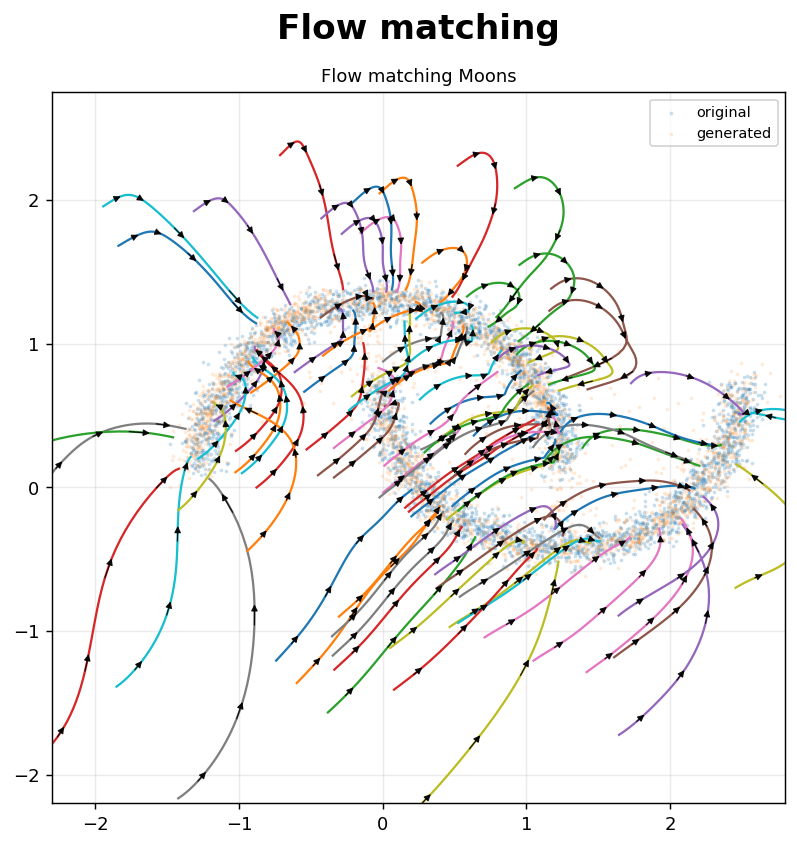

In [10]:
fig, ax = plt.subplots(figsize=(8.2, 6.6), dpi=130)
fig.suptitle("Flow matching", fontsize=19, fontweight="bold", y=0.98)

ax.scatter(
    moons[:, 0],
    moons[:, 1],
    s=4,
    color="tab:blue",
    alpha=0.24,
    linewidths=0,
    label="original",
)
ax.scatter(
    generated[:, 0],
    generated[:, 1],
    s=4,
    color="tab:orange",
    alpha=0.16,
    linewidths=0,
    label="generated",
)

for i in range(paths.shape[1]):
    curve = paths[:, i, :]
    color = plt.cm.tab10(i % 10)
    ax.plot(curve[:, 0], curve[:, 1], color=color, lw=1.25)

    arrow_ids = np.linspace(5, len(curve) - 6, 4, dtype=int)
    for j in arrow_ids:
        ax.annotate(
            "",
            xy=curve[j + 2],
            xytext=curve[j],
            arrowprops=dict(
                arrowstyle="-|>",
                color="black",
                lw=0.65,
                mutation_scale=7.5,
                shrinkA=0,
                shrinkB=0,
                alpha=0.9,
            ),
        )

ax.set_title("Flow matching Moons", fontsize=10)
ax.set_xlim(-2.3, 2.8)
ax.set_ylim(-2.2, 2.75)
ax.set_aspect("equal", adjustable="box")
ax.grid(True, alpha=0.25)
ax.legend(loc="upper right", frameon=True, fontsize=8)
plt.tight_layout()
plt.show()


## Section 3 Application à de vrais images

In [11]:
class DoubleConv(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()

        self.net = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1),
            nn.ReLU(),
        )

    def forward(self, x):
        return self.net(x)

In [20]:
class UNet(nn.Module):
    def __init__(self, in_dim=2, hidden_dim=32, out_dim=1):
        super().__init__()

        self.enc1 = DoubleConv(in_dim, hidden_dim)              # 2 -> 32
        self.pool1 = nn.MaxPool2d(kernel_size=2, stride=2)      # 28 -> 14

        self.enc2 = DoubleConv(hidden_dim, hidden_dim * 2)      # 32 -> 64
        self.pool2 = nn.MaxPool2d(kernel_size=2, stride=2)      # 14 -> 7

        self.bottleneck = DoubleConv(hidden_dim * 2, hidden_dim * 2)

        self.up1 = nn.ConvTranspose2d(
            hidden_dim * 2, hidden_dim * 2, kernel_size=2, stride=2
        )
        self.dec1 = DoubleConv(hidden_dim * 2, hidden_dim)

        self.up2 = nn.ConvTranspose2d(
            hidden_dim, hidden_dim, kernel_size=2, stride=2
        )
        self.dec2 = DoubleConv(hidden_dim, hidden_dim)

        self.out = nn.Conv2d(hidden_dim, out_dim, kernel_size=1)

    def forward(self, x, t):
    
        t = t.view(-1, 1, 1, 1)

        t_map = t.expand(-1, 1, x.shape[2], x.shape[3])
        x = torch.cat([x, t_map], dim=1)  # (B, 2, 28, 28)

        e1 = self.enc1(x)        # (B, 32, 28, 28)
        p1 = self.pool1(e1)      # (B, 32, 14, 14)

        e2 = self.enc2(p1)       # (B, 64, 14, 14)
        p2 = self.pool2(e2)      # (B, 64, 7, 7)

        b = self.bottleneck(p2)  # (B, 64, 7, 7)

        d1 = self.up1(b)         # (B, 64, 14, 14)
        d1 = d1 + e2             # skip connection
        d1 = self.dec1(d1)       # (B, 32, 14, 14)

        d2 = self.up2(d1)        # (B, 32, 28, 28)
        d2 = d2 + e1             # skip connection
        d2 = self.dec2(d2)       # (B, 32, 28, 28)

        return self.out(d2)      # (B, 1, 28, 28)

In [ ]:
transform = transforms.Compose([
    transforms.ToTensor(),
])

train_dataset = datasets.MNIST(
    root="./data",
    train=True,
    download=True,
    transform=transform,
)

train_loader = DataLoader(
    train_dataset,
    batch_size=128,
    shuffle=True,
)


def show_images(images, n=16, title=None):
    images = images[:n].detach().cpu()
    cols = 4
    rows = (n + cols - 1) // cols

    plt.figure(figsize=(cols * 2, rows * 2))
    if title is not None:
        plt.suptitle(title)

    for i in range(n):
        plt.subplot(rows, cols, i + 1)
        plt.imshow(images[i].squeeze(0), cmap="gray")
        plt.axis("off")

    plt.tight_layout()
    plt.show()


In [17]:
def interpolate_flow(x0, x1, t, interpolation="linear"):
    t_view = t.view(-1, 1, 1, 1)

    if interpolation == "linear":
        xt = (1 - t_view) * x0 + t_view * x1
        target_velocity = x1 - x0

    elif interpolation == "cos":
        angle = torch.pi * t_view / 2
        alpha = torch.cos(angle)
        beta = torch.sin(angle)

        d_alpha = -(torch.pi / 2) * torch.sin(angle)
        d_beta = (torch.pi / 2) * torch.cos(angle)

        xt = alpha * x0 + beta * x1
        target_velocity = d_alpha * x0 + d_beta * x1

    else:
        raise ValueError("interpolation doit etre 'linear' ou 'cos'")

    return xt, target_velocity

In [18]:
def train_unet_flow_matching(
    model,
    train_loader,
    epochs=10,
    interpolation="linear",
    lr=1e-3,
    optimizer=None,
    device=device,
):
    model = model.to(device)

    if optimizer is None:
        optimizer = torch.optim.AdamW(model.parameters(), lr=lr)

    loss_history = []
    model.train()

    for epoch in range(epochs):
        epoch_loss = 0.0

        for x1, _ in tqdm(train_loader, desc=f"Epoch {epoch + 1}/{epochs}"):
            x1 = x1.to(device)
            x1 = x1 * 2 - 1

            x0 = torch.randn_like(x1)
            t = torch.rand(x1.shape[0], device=device)

            xt, target_velocity = interpolate_flow(
                x0,
                x1,
                t,
                interpolation=interpolation,
            )

            pred_velocity = model(xt, t)
            loss = F.mse_loss(pred_velocity, target_velocity)

            optimizer.zero_grad(set_to_none=True)
            loss.backward()
            optimizer.step()

            epoch_loss += loss.item()

        avg_loss = epoch_loss / len(train_loader)
        loss_history.append(avg_loss)
        print(f"Epoch {epoch + 1}/{epochs} | {interpolation} | loss = {avg_loss:.6f}")

    return loss_history


In [19]:
@torch.no_grad()
def simulate_unet_flow_matching(
    model,
    n_images=16,
    steps=100,
    image_size=28,
    save_steps=None,
    return_trajectory=False,
    device=device,
):
    model = model.to(device)
    model.eval()

    x = torch.randn(n_images, 1, image_size, image_size, device=device)
    dt = 1.0 / steps

    if save_steps is None:
        save_steps = [0, steps // 4, steps // 2, 3 * steps // 4, steps]

    save_steps = sorted(set(int(s) for s in save_steps if 0 <= int(s) <= steps))
    save_steps_set = set(save_steps)
    trajectory = []
    trajectory_steps = []

    def normalize_for_display(x):
        return ((x + 1) / 2).clamp(0, 1).detach().cpu()

    if return_trajectory and 0 in save_steps_set:
        trajectory.append(normalize_for_display(x))
        trajectory_steps.append(0)

    for i in tqdm(range(steps), desc="Simulation"):
        t = torch.full((n_images,), i / steps, device=device)
        velocity = model(x, t)
        x = x + dt * velocity

        current_step = i + 1
        if return_trajectory and current_step in save_steps_set:
            trajectory.append(normalize_for_display(x))
            trajectory_steps.append(current_step)

    x = (x + 1) / 2
    final_images = x.clamp(0, 1)

    if return_trajectory:
        return final_images, torch.stack(trajectory), trajectory_steps

    return final_images


def show_simulation_steps(trajectory, trajectory_steps=None, n_images=8):
    trajectory = trajectory[:, :n_images].detach().cpu()
    n_steps, n_images = trajectory.shape[:2]

    fig, axes = plt.subplots(
        n_steps,
        n_images,
        figsize=(1.5 * n_images, 1.5 * n_steps),
        squeeze=False,
    )

    for row in range(n_steps):
        for col in range(n_images):
            axes[row, col].imshow(trajectory[row, col].squeeze(0), cmap="gray")
            axes[row, col].axis("off")

        if trajectory_steps is not None:
            axes[row, 0].set_ylabel(
                f"step {trajectory_steps[row]}",
                rotation=0,
                labelpad=35,
                va="center",
            )

    plt.tight_layout()
    plt.show()

In [14]:
model_cos = UNet()
losses_cos = train_unet_flow_matching(model_cos, train_loader, epochs=10, interpolation="cos")

Epoch 1/10:   0%|          | 0/469 [00:00<?, ?it/s]

Epoch 1/10 | cos | loss = 0.705107


Epoch 2/10:   0%|          | 0/469 [00:00<?, ?it/s]

Epoch 2/10 | cos | loss = 0.415021


Epoch 3/10:   0%|          | 0/469 [00:00<?, ?it/s]

...

Epoch 8/10 | cos | loss = 0.332216


Epoch 9/10:   0%|          | 0/469 [00:00<?, ?it/s]

Epoch 9/10 | cos | loss = 0.325673


Epoch 10/10:   0%|          | 0/469 [00:00<?, ?it/s]

Epoch 10/10 | cos | loss = 0.338185


Simulation:   0%|          | 0/100 [00:00<?, ?it/s]

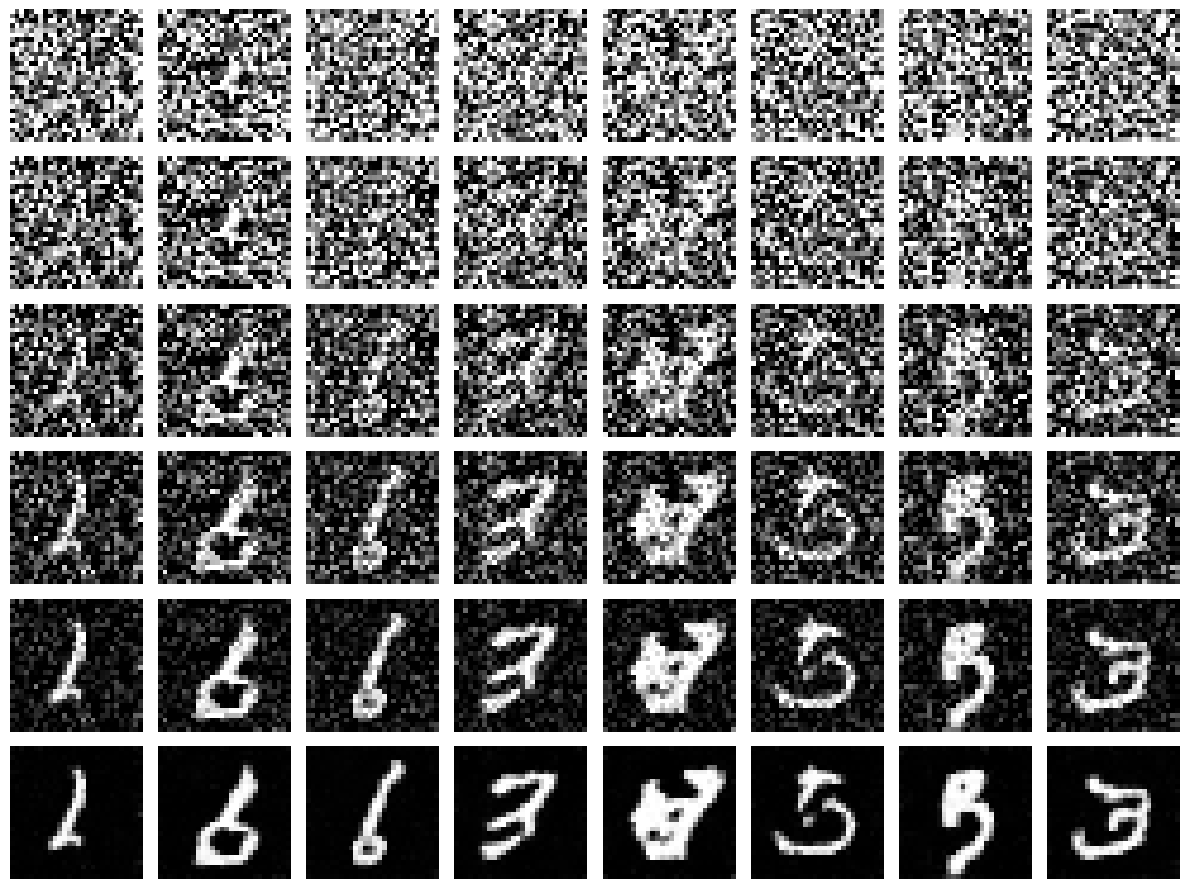

In [16]:
generated, trajectory, trajectory_steps = simulate_unet_flow_matching(
     model_cos,
     n_images=8,
     steps=100,
     save_steps=[0, 20, 40, 60, 80, 100],
     return_trajectory=True,
 )
show_simulation_steps(trajectory, trajectory_steps, n_images=8)